Предикт цены

In [18]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

In [12]:
import pandas as pd
import numpy as np
import torch
from sklearn.preprocessing import MinMaxScaler

df = pd.read_csv('EtherMarketCapChart.csv')

df['Price'] = df['Price'].replace({',': ''}, regex=True).astype(float)

data = df['Price'].values.reshape(-1, 1)

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        x = data[i:(i + seq_length)]
        y = data[i + seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

seq_length = 20
X, y = create_sequences(scaled_data, seq_length)

X = torch.from_numpy(X).float()
y = torch.from_numpy(y).float()

print(f"Формат X: {X.shape}")
print(f"Формат y: {y.shape}")

Формат X: torch.Size([1144, 20, 1])
Формат y: torch.Size([1144, 1])


In [13]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_layer_size=64, output_size=1, num_layers=2):
        super().__init__()
        self.hidden_layer_size = hidden_layer_size
        self.lstm = nn.LSTM(input_size, hidden_layer_size, num_layers, batch_first=True, dropout=0.2)
        self.linear = nn.Linear(hidden_layer_size, output_size)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_step = lstm_out[:, -1, :]
        prediction = self.linear(last_step)
        return prediction

model = LSTMModel()

In [14]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 50
model.train()

for epoch in range(epochs):
    optimizer.zero_grad()
    y_pred = model(X)
    loss = criterion(y_pred, y)
    loss.backward()
    optimizer.step()

    if (epoch+1) % 10 == 0:
        print(f'Epoch {epoch+1}/{epochs}, Loss: {loss.item():.6f}')

Epoch 10/50, Loss: 0.040314
Epoch 20/50, Loss: 0.032556
Epoch 30/50, Loss: 0.006099
Epoch 40/50, Loss: 0.002686
Epoch 50/50, Loss: 0.001688


In [15]:
model.eval()
with torch.no_grad():
    predictions = model(X).numpy()
    predictions_rescaled = scaler.inverse_transform(predictions)
    real_prices = scaler.inverse_transform(y.numpy())

print(f"Последняя предсказанная цена: {predictions_rescaled[-1][0]:.2f}")

Последняя предсказанная цена: 210.48


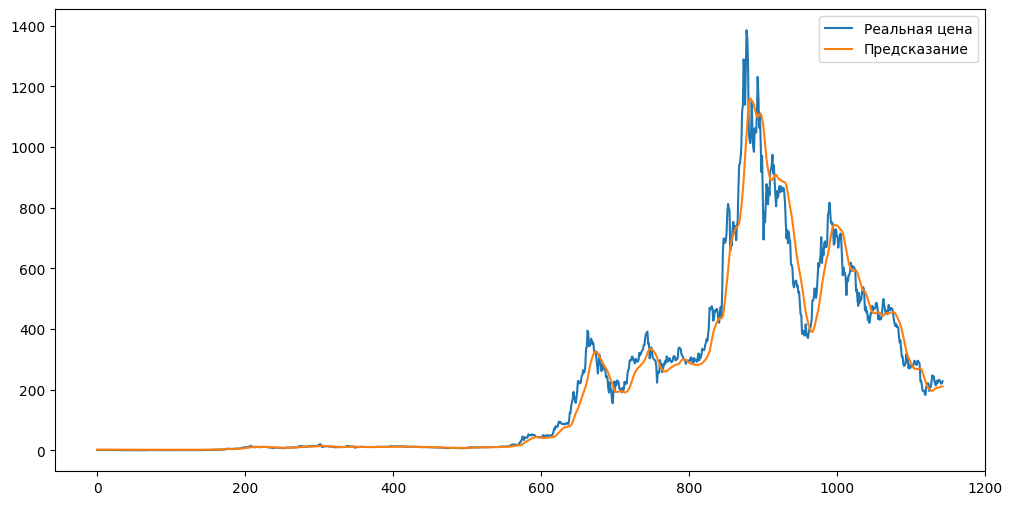

In [17]:
plt.figure(figsize=(12,6))
plt.plot(real_prices, label='Реальная цена')
plt.plot(predictions_rescaled, label='Предсказание')
plt.legend()
plt.show()

In [20]:
mae = mean_absolute_error(real_prices, predictions_rescaled)
print(f"Средняя ошибка: {mae:.2f}")

Средняя ошибка: 27.08
